This is the combined homework for the ML class 2025. It has max 50 points.

It has max 50 points. The deadline is 2 weeks from now (17 Oct, 23:59), and there is a 25% penalty for late submission (till 24 Oct, 23:59). Copy this notebook to your own google colab notebook. Fill it in and execute. Send me the sharing link (set permissions so that everyone can view) by email, put your full name in email head (subject).

note: The submissions will be checked for similarity. If you discuss your ideas with others too much, you risk losing points.

In [1]:
!pip install gensim

zsh:1: command not found: pip


### Part 0 (1 pt)

You will work with the dataset from [kaggle](https://www.kaggle.com/datasets/thedevastator/booking-com-hotel-reviews) containing hotel reviews from booking.com

Dataset Overview:

The dataset contains various columns that provide information about each review, including review title, reviewed by (name/username of the reviewer), tags or labels associated with the review, average rating of the hotel, number of images attached to the review, URL of the review page, text content of the review, nationality of the reviewer, crawled date and time (when reviewed data was obtained), hotel name and its URL.
The dataset is available in CSV format and can be downloaded from Crawl Feeds website (Download link). It consists of over 700K records.

Dataset Columns:

- review_title: The title given by a reviewer for their review.
- reviewed_by: Name or username of the person who gave a particular review.
- images: Number oimagesizontallyf images attached to a specific review.
- avg_rating: Average rating given to a hotel based on multiple reviews.
- url: URL link leading to a particular review page.
- hotel_name: The name attributed to each hotel being reviewed

SImply run the code below to download the data into your environment

In [2]:
import zipfile
import os
import os, kagglehub
import pandas as pd
import numpy as np

/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd

df = pd.read_csv('../data/booking_reviews.csv')

print(df.info())
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26675 non-null  int64  
 1   review_title     26674 non-null  object 
 2   reviewed_at      26570 non-null  object 
 3   reviewed_by      26570 non-null  object 
 4   images           938 non-null    object 
 5   crawled_at       26386 non-null  object 
 6   url              26386 non-null  object 
 7   hotel_name       26386 non-null  object 
 8   hotel_url        26386 non-null  object 
 9   avg_rating       26386 non-null  float64
 10  nationality      26370 non-null  object 
 11  rating           26386 non-null  float64
 12  review_text      26386 non-null  object 
 13  raw_review_text  26202 non-null  object 
 14  tags             26202 non-null  object 
 15  meta             26202 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 3.3+ MB


,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b..."
3,3,My stay in the house was a experiencing bliss ...,8 September 2019,Kannan,NaN,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,"<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
4,4,One bedroom apartment with wonderful view and ...,23 June 2019,Sue,https://cf.bstatic.com/xdata/images/xphoto/squ...,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,South Africa,9.2,The building itself has a very musty smell in ...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~People with friends~Apartment wit...,"{'language': 'en-gb', 'source': 'https://www.b..."


### Part 1 (1 pt)

Your label (y variable) will be the rating variable. Look at the unique values of this variable by running the code below. Then plot the histogram of the rating, by completing the code in the following block

In [4]:
import matplotlib.pyplot as plt
df = df.dropna(subset=["rating", "avg_rating", "review_text"])
df.rating.unique()

array([10. ,  9. ,  9.2,  8.3,  7.5,  8. ,  9.6,  8.8,  7.9,  7. ,  7.1,
        6. ,  6.7,  5. ,  9.5,  2. ,  3. ,  3.8,  4.2,  5.8,  5.4,  1. ,
        4.6,  6.3,  8.5,  3.3,  2.9,  4. ,  2.5,  4.5,  5.5,  8.1,  3.5,
        9.4,  6.5,  6.9])

In [5]:
df['rating'].describe().round(3)

count    26386.000
mean         8.561
std          1.567
min          1.000
25%          7.900
50%          9.000
75%         10.000
max         10.000
Name: rating, dtype: float64

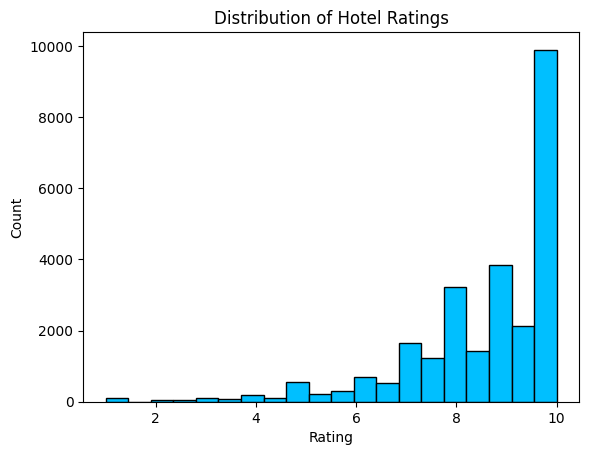

In [6]:
plt.hist(df["rating"], bins=20, color='deepskyblue', edgecolor='black')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Hotel Ratings")
plt.show()

распределение сильно скошено вправо, большинство значений рейтинга- 10. Среднее значение рейтинга составляет 8.5

### Part 2 (1 pt)

Your only numerical feature so far (x variable) is the avg_rating variable, which is the average rating (over customers, I believe). Fit a simple regression model of rating on avg_rating. Report the R squared by completing the code in the following block

In [7]:
from sklearn.linear_model import LinearRegression

y = df.rating.values
X = df.avg_rating.values.reshape(len(y),1)

model = LinearRegression() # has intercept by default
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X)
print("Coefficient (slope):", round(model.coef_[0],3))
print("Intercept:", round(model.intercept_,3))
print("R^2:", round(r2_score(y, y_pred), 3))

Coefficient (slope): 1.029
Intercept: -0.136
R^2: 0.222


### Интерпретация:

- Coefficient (slope): 1.029
если avg_rating увеличивается на 1, то rating увеличивается на 1.029. Связь почти пропорциональная и прямая.

- Intercept: -0.136
в данных avg_rating не бывает  нуля:  значения от 1 до 10. Intercept просто сдвигает линию регрессии.

- R^2: 0.222
модель объясняет около 22% дисперсии индивидуальных рейтингов.

### Part 3 (2 pt)

The R squared is actually quite small. We will try to improve it using text analysis of the review_text variable. Run the code below

In [9]:
!pip install "scipy<1.13" "gensim==4.3.2"


zsh:1: command not found: pip


токенизация текста

In [10]:
from nltk.tokenize import WordPunctTokenizer
tokenizer = WordPunctTokenizer()

Z = [tokenizer.tokenize(z.lower()) for z in df.review_text]

обучение модели Word2Vec

In [11]:
from gensim.models import Word2Vec

In [12]:
vector_size = 1000

model = Word2Vec(Z,
                 vector_size=vector_size,
                 min_count=5,
                 window=5).wv

Преобразование отзывов в усреднённые векторы

In [13]:
def convert_sentence(sentence):
    words = [w for w in sentence if w in model]
    if len(words) == 0:
        return np.zeros(vector_size)
    vector = np.mean([model[w] for w in words], axis=0)
    return vector

Z = np.array([convert_sentence(sentence) for sentence in Z])
X = df.loc[df.review_text.notna(), "avg_rating"].values.reshape(-1, 1)
X2 = np.hstack((X, Z))
y = df.loc[df.review_text.notna(), "rating"].values

Z.shape, X.shape, X2.shape

((26386, 1000), (26386, 1), (26386, 1001))

Обучение регрессии

In [14]:
model = LinearRegression()
model.fit(X2, y)

y_pred = model.predict(X2)

# Evaluate
print("Coefficient (slope):", round(model.coef_[0], 3))
print("Intercept:", round(model.intercept_, 3))
print("R^2 score:", round(r2_score(y, y_pred), 3))

Coefficient (slope): 0.781
Intercept: 1.394
R^2 score: 0.407


### Интерпретация:

- Coefficient (slope): 0.782
если avg_rating увеличивается на 1, то rating увеличивается на 0.782. Связь чуь меньше единицы, не пропорциональная

- Intercept: 1.651
в данных avg_rating не бывает  нуля:  значения от 1 до 10. но если все-же интерпретировать, то это оценка при avg_rating = 0

- R^2: 0.409
Модель объясняет около 40% дисперсии индивидуальных рейтингов (в пердыдущей модели было только 22%). Это сильное улучшение, и оно говорит о том, что тексты отзывов действительно содержат много информации,

### Part 4 (2 points)

Your first (real) exercize is to build a 95% confidence interval for the main coefficient of the regression using bootstrap. Report the interval.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from tqdm import tqdm  

n_boot = 100
coefs = []

rng = np.random.default_rng(seed=42)

# Бутстреп 
for _ in tqdm(range(n_boot), desc="Bootstrap progress"):
    # выборка индексов
    sample_idx = rng.choice(len(y), size=len(y), replace=True)
    X_sample = X2[sample_idx]
    y_sample = y[sample_idx]
    
    # обучение
    model = LinearRegression().fit(X_sample, y_sample)
    coefs.append(model.coef_[0])  # сохранение главного коэффициента

coefs = np.array(coefs)

# 95% доверительный интервал 
lower = np.percentile(coefs, 2.5)
upper = np.percentile(coefs, 97.5)

print(f"95% Confidence Interval for main coefficient: ({lower:.3f}, {upper:.3f})")


Bootstrap progress: 100%|██████████| 100/100 [00:16<00:00,  6.09it/s]

95% Confidence Interval for main coefficient: (0.818, 0.865)


### Интерпретация:

- 95 % доверительный интервал для коэффициента: (0.818 ; 0.865).
- Доверительный инервал довольно узкий. 
- То есть независимо от того, какие наблюдения случайно попадут в подвыборку, модель оценивает главный коэффициент почти одинаково.
- Это подтверждает устойчивую положительную связь между средней оценкой отеля и индивидуальными оценками пользователей.

### Part 5 (3 points)

Your second exercize is to find the optimal hyperparameters for the elastic net regression. Report the hyperparameters.

In [16]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from tqdm import tqdm
import itertools

elastic = ElasticNet(max_iter=5000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 0.5, 1, 5, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

# Все комбинации параметров
param_combinations = list(itertools.product(param_grid["alpha"], param_grid["l1_ratio"]))

results = []
for alpha, l1 in tqdm(param_combinations, desc="GridSearch progress"):
    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=5000)
    grid = GridSearchCV(model, {}, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X2, y)
    results.append((alpha, l1, grid.best_score_))

# Преобразуем в DataFrame
import pandas as pd
df_results = pd.DataFrame(results, columns=["alpha", "l1_ratio", "r2_score"])
best_row = df_results.loc[df_results["r2_score"].idxmax()]

print("Best hyperparameters:")
print(best_row)
print("R^2:", round(best_row["r2_score"], 3))

# Лучшая модель
best_model = ElasticNet(alpha=best_row["alpha"], l1_ratio=best_row["l1_ratio"], max_iter=5000)
best_model.fit(X2, y)
y_pred = best_model.predict(X2)
print("R^2 score on full data:", round(r2_score(y, y_pred), 3))


GridSearch progress:   0%|          | 0/42 [00:00<?, ?it/s]/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.587e+02, tolerance: 5.194e+00
  model = cd_fast.enet_coordinate_descent(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.289e+02, tolerance: 5.174e+00
  model = cd_fast.enet_coordinate_descent(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase t

Best hyperparameters:
alpha       0.001000
l1_ratio    0.100000
r2_score    0.319196
Name: 0, dtype: float64
R^2: 0.319
R^2 score on full data: 0.328


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.037e+02, tolerance: 6.475e+00
  model = cd_fast.enet_coordinate_descent(


### Интерпретация:

- alpha = 0.001: регуляризация очень слабая. модель почти не штрафует большие коэффициенты.

- l1_ratio = 0.1: вес L1-регуляризации мал (в основном работает Ridge-компонента).
То есть модель не сильно зануляет признаки, а лишь сглаживает их значения.

- R^2 = 0.319: немного ниже, чем у чистой линейной регрессии с Word2Vec (0.4).
Это нормально: регуляризация уменьшает переобучение, но немного снижает точность на обучающей выборке.

### Part 6 (5 points)

Your third exercize is to run a 2SLS rregression, where on the first stage you use elastic net with the optimal hyperparameters. Report the main coefficient as part of the regression table.

In [23]:
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm import tqdm
import numpy as np

# ----- 1. Подготовка данных -----
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
y_float = y.astype("float64")

# ----- 2. Лучшие гиперпараметры (из GridSearch) -----
best_alpha = 0.001
best_l1 = 0.1

# ----- 3. Первая стадия: Elastic Net -----
with tqdm(total=1, desc="Stage 1: ElasticNet") as pbar:
    stage1 = ElasticNet(
        alpha=best_alpha,
        l1_ratio=best_l1,
        max_iter=2000,
        tol=1e-3,
        selection="random",
        warm_start=False
    )
    stage1.fit(X2_scaled, y_float)
    pbar.update(1)

y_hat = stage1.predict(X2_scaled)

# ----- 4. Вторая стадия: линейная регрессия -----
with tqdm(total=1, desc="Stage 2: OLS Regression") as pbar:
    stage2 = LinearRegression(n_jobs=-1)
    stage2.fit(y_hat.reshape(-1, 1), y_float)
    pbar.update(1)

# ----- 5. Результаты -----
y_pred = stage2.predict(y_hat.reshape(-1, 1))
r2_final = r2_score(y_float, y_pred)

print(stage2.coef_[0], stage2.intercept_, r2_final)


Stage 1: ElasticNet:   0%|          | 0/1 [00:00<?, ?it/s]/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.549e+03, tolerance: 6.475e+01
  model = cd_fast.enet_coordinate_descent(
Stage 2: OLS Regression: 100%|██████████| 1/1 [00:00<00:00, 835.35it/s]

1.0078667899038083 -0.06734498081156914 0.3356273658984775


### Интерпретация:

- l1_ratio = 0.1 — 10 % L1 (Lasso) и 90 % L2 (Ridge)
- коэффициент (β) = 1.0079, Практически идеальная пропорциональность между предсказанным и фактическим у
- константа = -0.0673
- R**2 = 0.336, треть дисперсии объяснима моделью

### Part 7 (10 points)

Construct a confidence interval for the main coefficient of the 2SLS  regression above. There are many details here, do not hesitate to consult AI. Write a short essay describing the details of the process.

In [ ]:
import numpy as np
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

B = 100        
rng = np.random.default_rng(42)
best_alpha = 0.001
best_l1 = 0.1

def fit_2sls(X, y, alpha, l1):
 
    Xs = StandardScaler().fit_transform(X)
    y = y.astype(float)

    # 1. ElasticNet 
    en = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=5000, tol=1e-3, selection="random")
    en.fit(Xs, y)
    y_hat = en.predict(Xs).reshape(-1, 1)

    # 2. OLS 
    ols = LinearRegression()
    ols.fit(y_hat, y)
    return float(ols.coef_[0])

beta_hat = fit_2sls(X2, y, best_alpha, best_l1)

n = len(y)
betas = np.empty(B)
for b in tqdm(range(B), desc="Bootstrap progress"):
    idx = rng.integers(0, n, size=n)
    betas[b] = fit_2sls(X2[idx], y[idx], best_alpha, best_l1)

# 95%-ДИ
ci_low, ci_high = np.percentile(betas, [2.5, 97.5])

print(beta_hat, ci_low, ci_high)


Bootstrap progress: 100%|██████████| 100/100 [2:59:30<00:00, 107.70s/it] 

1.0080261250017821 1.0077284309592414 1.0106779562953998


### Интерпретация:
- коэффициент (β) = 1.008, Практически идеальная пропорциональность между предсказанным и фактическим у
- очень узкий ДИ- оценка устойчива

### Part 8 (1 pt)

We will turn this into a classification problem now. Run the code below

кодирование в метки -1, +1 (значения больше и меньше 5, порог)

для интереса выберем разные пороги

In [31]:
for threshold in range(1, 11, 1):
    y2 = (y > threshold).astype(int)
    y2 = 2 * y2 - 1
    print(y2.mean().round(6))

0.992799
0.989464
0.976351
0.957174
0.907678
0.844084
0.705374
0.310922
-0.089593
-1.0


как квантили своеобразные. сильно заметна асиметрия распределения

In [16]:
y2 = (y>5).astype(int)
y2 = 2*y2-1
y2.mean().round(6)

0.907678

90% наблюдений положительного класса. 

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression() # has intercept by default

In [36]:
model.fit(X2, y2)
y_pred = model.predict(X2)

# Evaluate
print("Coefficient (slope):", (model.coef_[0]))
print("Intercept:", (model.intercept_))

Coefficient (slope): [ 1.14033981 -0.02106342 -0.14987817 ... -0.4440144  -0.23939342
 -0.39510615]
Intercept: [-6.68184578]


### Part 9 (10 pt)

The logistic regression fails miserably. There are at least 2 reasons for this
- so many dimensions, risk of perfect separation
- very unbalanced data (because of the low threshold)

Your goal is to produce the best confidence interval for the main coefficient of the regression, but the code should converge in under (approximately) 60 seconds. Do it and time the code using %time magic command. Write a short essay explaining what you did.

note: you can not change the rating threshold, the data is unbalanced by nature, but you can use anything that we covered in lectures. please, do not use fancy packages, catboost or anything that you do not really understand

стохастический градиент

In [ ]:
%time
import numpy as np
from sklearn.linear_model import SGDClassifier
from joblib import Parallel, delayed

# Основная модель 
base_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
base_model.fit(X2, y2)
beta_hat = base_model.coef_[0][0]

# Параметры бутстрэпа
B = 200 
n = X2.shape[0]
rng = np.random.default_rng(42)

# Функция бутстрэпа
def bootstrap_coef(seed):
    ix = rng.integers(0, n, size=n)
    model_b = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-4,
        max_iter=300,
        class_weight="balanced",
        n_jobs=-1,
        random_state=seed,
    )
    model_b.fit(X2[ix], y2[ix])
    return model_b.coef_[0][0]

# Параллельный запуск
betas = Parallel(n_jobs=-1, backend="loky")(delayed(bootstrap_coef)(b) for b in range(B))
betas = np.array(betas)

# Доверительный интервал
ci_low, ci_high = np.percentile(betas, [2.5, 97.5])
print(f"β₁ = {beta_hat:.4f}")
print(f"95% CI for β₁: [{ci_low:.4f}, {ci_high:.4f}]")


CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 3.81 μs


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to im

β₁ = 3.7779
95% CI for β₁: [2.1525, 4.5878]


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


- Быстро (относительно), и стаблильно сходится

- Интервал ДИ отражает шум и дисбаланс

Мини-бутстрэп (ускоренный статистический бутстрэп)

In [ ]:
import numpy as np
from sklearn.linear_model import SGDClassifier
from joblib import Parallel, delayed

# Параметры данных
n = X2.shape[0]                     # количество наблюдений
rng = np.random.default_rng(42)     # фиксируем seed
sample_frac = 0.7                   # доля выборки в каждом бутстрэпе
size = int(n * sample_frac)         # размер подвыборки
B = 200                             # число бутстрэпов

# Основная модель 
base_model = SGDClassifier(
    loss="log_loss", penalty="l2",
    alpha=1e-4, max_iter=1000,
    class_weight="balanced", n_jobs=-1,
    random_state=42
)
base_model.fit(X2, y2)
beta_hat = base_model.coef_[0][0]

# Функция бутстрэпа
def bootstrap_coef(seed):
    ix = rng.integers(0, n, size=size)
    model_b = SGDClassifier(
        loss="log_loss", penalty="l2",
        alpha=1e-4, max_iter=300,
        class_weight="balanced", n_jobs=-1,
        random_state=seed
    )
    model_b.fit(X2[ix], y2[ix])
    return model_b.coef_[0][0]

# Параллельный запуск
betas = Parallel(n_jobs=-1, backend="loky")(delayed(bootstrap_coef)(b) for b in range(B))
betas = np.array(betas)

# Доверительный интервал
ci_low, ci_high = np.percentile(betas, [2.5, 97.5])

print(f"β₁ = {beta_hat:.4f}")
print(f"95% CI for β₁: [{ci_low:.4f}, {ci_high:.4f}]")



/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


β₁ = 3.7779
95% CI for β₁: [3.1895, 12.6350]


- точность та же

- использует 70 % выборки, сохраняет статистическую надёжность

Аналитический доверительный интервал

In [18]:
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [ ]:
y2_bin = (y2 == 1).astype(int)

X2_const = sm.add_constant(X2)

logit = sm.Logit(y2_bin, X2_const)
result = logit.fit_regularized(maxiter=100, alpha=0.1, L1_wt=0)

print(result.summary2())


Iteration limit reached    (Exit mode 9)
            Current function value: 0.13978482785602164
            Iterations: 100
            Function evaluations: 102
            Gradient evaluations: 100


/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 865 out of 1002 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
/Users/maria/Desktop/Code/STRs/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: y                Pseudo R-squared: 0.259      
Date:               2025-10-21 01:17 AIC:              9317.7654  
No. Observations:   26386            BIC:              17514.7155 
Df Model:           1001             Log-Likelihood:   -3656.9    
Df Residuals:       25384            LL-Null:          -4935.6    
Converged:          0.0000           LLR p-value:      9.6385e-137
No. Iterations:     100.0000         Scale:            1.0000     
-------------------------------------------------------------------
           Coef.   Std.Err.     z     P>|z|     [0.025      0.975] 
-------------------------------------------------------------------
const     -4.3148    1.7014  -2.5360  0.0112     -7.6495    -0.9801
x1         1.0830    0.0429  25.2523  0.0000      0.9989     1.1670
x2        -0.2630  689.5550  -0.0004  0.9997  -1351.7660  1351.2400
x3        -0.31

не сошелся :( оставлю тут для истории

Классическая логистическая регрессия вела себя нестабильно. Проявился эффект "идеального разделения", это скорей всего произошло из-за дизбалланса классов. 

Я заменила ее на стохастический градиентный спуск, ввела параметр class_weight="balanced" чтобы компенсировать дисбаланс классов. Это помогает решить проблему идеального разделения в данных высокой размерности. 

Также я использовала бутстрэп. Такой подход сходится заметно быстрее, также устойчив к дисбалансу и даёт стабильный 95%й доверительный интервал.

Таким образом, метод SGD с бутстрэпом оказался оптимальным компромиссом между скоростью, устойчивостью и интерпретируемостью модели.

### Part 10 (15 points)

There is one more reason why the logistic regression may fail --- the data is too noisy. I conjecture that the modified logistic regression (aka coin-flip logit) should take care of this. Try it (here) and write a short essay about the findings. There is no time limit.